In [2]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.signal import butter, filtfilt, hilbert, find_peaks
from scipy import stats as spstats
import librosa
from IPython.display import Audio, display

from scipy.io import wavfile
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.model_selection import StratifiedGroupKFold, StratifiedKFold, cross_val_score, cross_val_predict
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, roc_curve, roc_auc_score, accuracy_score

%matplotlib inline
plt.rcParams['figure.figsize'] = (9, 3)
plt.rcParams['axes.grid'] = True

RNG = np.random.default_rng(42)
FS = 2000  # Hz — cuantas muestras por segundo va a tener nuestro audio de prueba

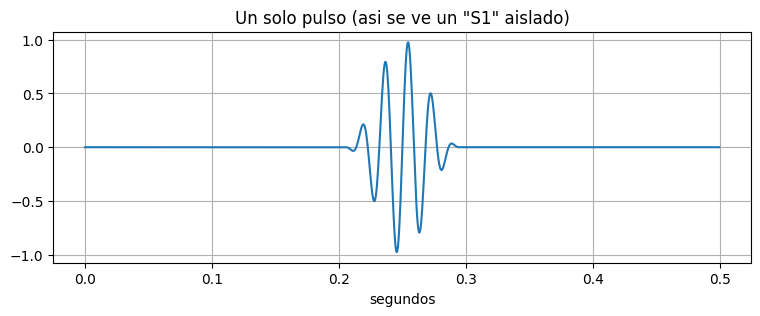

In [3]:
def hann_pulse(t, center, dur, freq, amp):
    out = np.zeros_like(t)                                  # empezamos en puro silencio
    mask = (t >= center - dur/2) & (t <= center + dur/2)     # que parte del tiempo cae dentro del pulso
    n = mask.sum()
    if n == 0:
        return out
    window = np.hanning(n)                                  # la envolvente: sube y baja suave
    carrier = np.sin(2*np.pi*freq*(t[mask]-center))          # el tono puro (seno)
    out[mask] = amp * window * carrier                       # tono x envolvente = pulso limpio
    return out

# probemoslo con un pulso aislado, para verlo solo
t = np.arange(0, 0.5, 1/FS)   # medio segundo, casi todo va a ser silencio
pulso = hann_pulse(t, center=0.25, dur=0.09, freq=55, amp=1.0)

plt.plot(t, pulso)
plt.title('Un solo pulso (asi se ve un "S1" aislado)')
plt.xlabel('segundos')
plt.show()

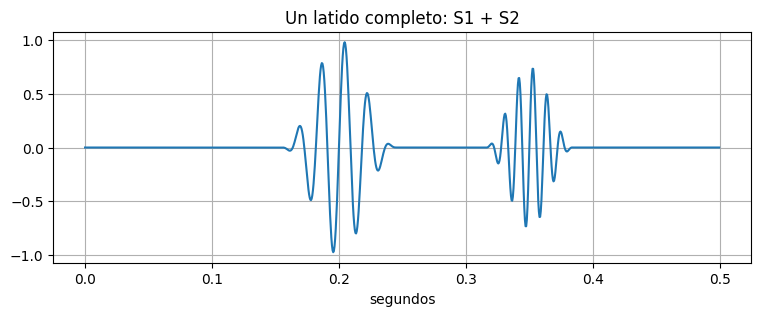

In [4]:
# S1: grave
s1 = hann_pulse(t, center=0.20, dur=0.09, freq=55, amp=1.0)

# S2: agudo
s2 = hann_pulse(t, center=0.35, dur=0.07, freq=90, amp=0.75)

latido = s1 + s2

plt.plot(t, latido)
plt.title('Un latido completo: S1 + S2')
plt.xlabel('segundos')
plt.show()

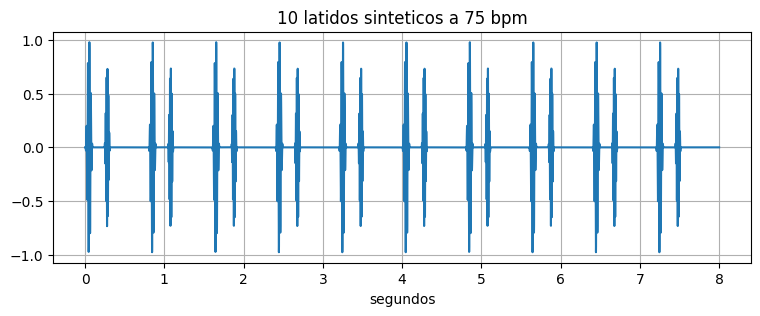

In [5]:
bpm = 75                       # latidos por minuto
cycle_len = 60.0 / bpm         # segundos que dura CADA latido
duracion = 8.0                 # segundos totales de la grabacion
t = np.arange(0, duracion, 1/FS)   # reloj nuevo, mas largo que el de antes

señal = np.zeros_like(t)
n_ciclos = int(duracion / cycle_len)

for i in range(n_ciclos):
    inicio_ciclo = i * cycle_len
    s1 = hann_pulse(t, center=inicio_ciclo + 0.05, dur=0.09, freq=55, amp=1.0)
    s2 = hann_pulse(t, center=inicio_ciclo + 0.35*cycle_len, dur=0.07, freq=90, amp=0.75)
    señal += s1 + s2

plt.plot(t, señal)
plt.title(f'{n_ciclos} latidos sinteticos a {bpm} bpm')
plt.xlabel('segundos')
plt.show()

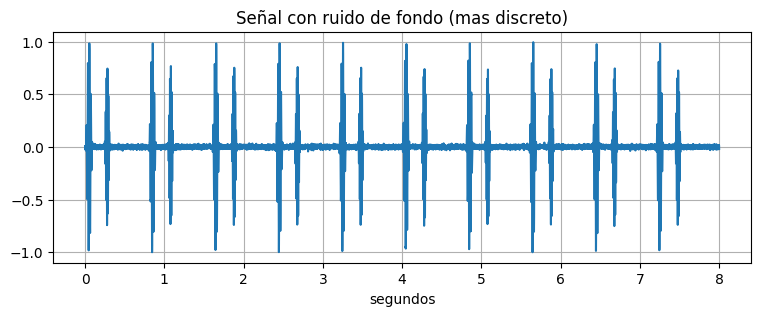

In [6]:
# normalizamos el latido SOLO (sin ruido todavia), para asegurar que los
# pulsos S1/S2 lleguen a su volumen maximo
señal_normalizada = señal / np.max(np.abs(señal))

# ruido bastante mas discreto que antes (0.01 en vez de 0.03)
ruido = RNG.normal(0, 0.01, size=t.shape)
señal_final = señal_normalizada + ruido

# por si el ruido empujo algun punto un poquito arriba de 1, reacomodamos otra vez
señal_final = señal_final / np.max(np.abs(señal_final))

plt.plot(t, señal_final)
plt.title('Señal con ruido de fondo (mas discreto)')
plt.xlabel('segundos')
plt.show()

audio_int16 = (señal_final * 32767).astype(np.int16)
wavfile.write('ejemplo_latido.wav', FS, audio_int16)
display(Audio('ejemplo_latido.wav'))

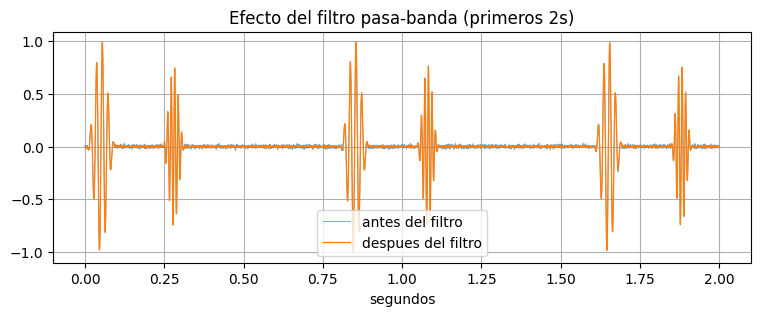

In [7]:
#pasabanda
def bandpass(sig, fs, low=25, high=400, order=4):
    nyquist = fs / 2
    b, a = butter(order, [low/nyquist, high/nyquist], btype='band')
    return filtfilt(b, a, sig)

señal_filtrada = bandpass(señal_final, FS)

plt.figure()
plt.plot(t[:int(2*FS)], señal_final[:int(2*FS)], linewidth=0.7, alpha=0.6, label='antes del filtro')
plt.plot(t[:int(2*FS)], señal_filtrada[:int(2*FS)], linewidth=0.9, label='despues del filtro')
plt.legend()
plt.xlabel('segundos')
plt.title('Efecto del filtro pasa-banda (primeros 2s)')
plt.show()

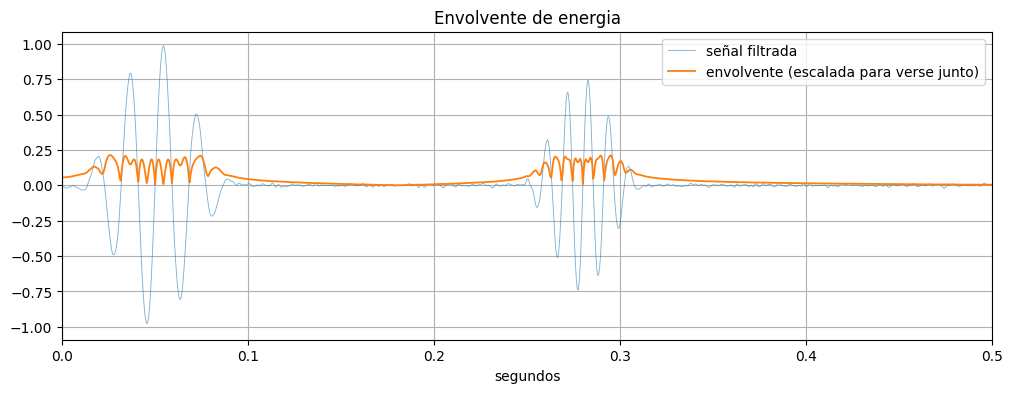

In [8]:
def shannon_envelope(sig):
    x = sig / np.max(np.abs(sig))
    energia = x**2
    energia = np.clip(energia, 1e-9, None)
    shannon = -energia * np.log(energia)
    envolvente = np.abs(hilbert(shannon))
    return envolvente

envolvente = shannon_envelope(señal_filtrada)

plt.figure(figsize=(12, 4))
t2 = t[:int(3*FS)]
plt.plot(t2, señal_filtrada[:int(3*FS)], linewidth=0.6, alpha=0.6, label='señal filtrada')
plt.plot(t2, envolvente[:int(3*FS)]*0.5, linewidth=1.3, label='envolvente (escalada para verse junto)')
plt.legend()
plt.xlabel('segundos')
plt.title('Envolvente de energia')
plt.xlim(0, .5)  # solo el primer .5s, en vez de los 3s completos
plt.show()

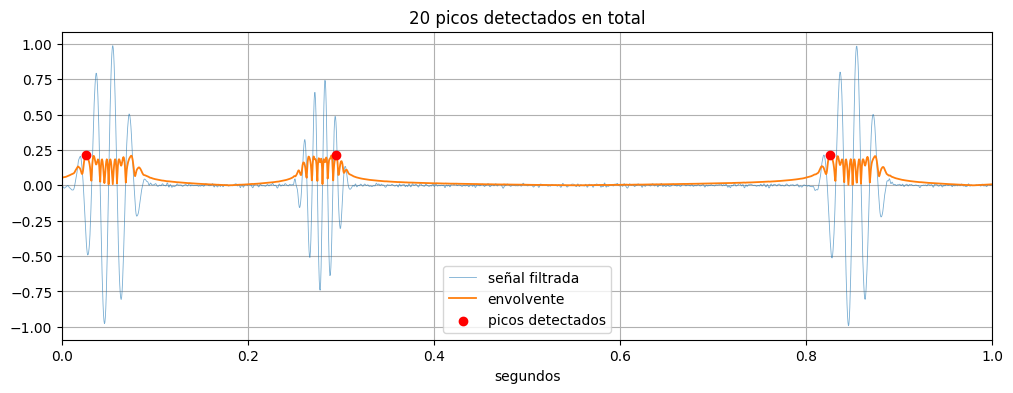

In [9]:
picos = find_peaks(envolvente, distance=int(FS*60/180/2.2), prominence=np.std(envolvente)*0.5)[0]

plt.figure(figsize=(12, 4))
t2 = t[:int(3*FS)]
plt.plot(t2, señal_filtrada[:int(3*FS)], linewidth=0.6, alpha=0.6, label='señal filtrada')
plt.plot(t2, envolvente[:int(3*FS)]*0.5, linewidth=1.3, label='envolvente')
picos_en_rango = picos[picos < int(3*FS)]
plt.scatter(t[picos_en_rango], envolvente[picos_en_rango]*0.5, color='red', zorder=5, label='picos detectados')
plt.legend()
plt.xlabel('segundos')
plt.xlim(0, 1)
plt.title(f'{len(picos)} picos detectados en total')
plt.show()

forma del resultado (filas, columnas): (8, 32)


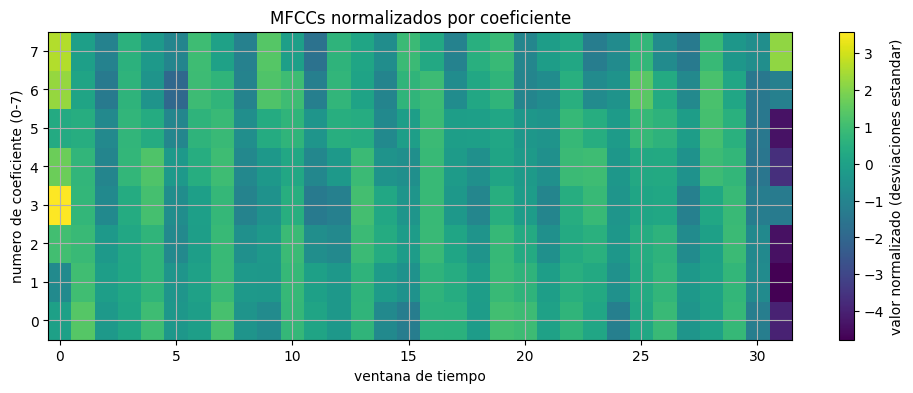

In [10]:
mfcc = librosa.feature.mfcc(y=señal_filtrada.astype(float), sr=FS, n_mfcc=8)
print("forma del resultado (filas, columnas):", mfcc.shape)
mfcc_normalizado = (mfcc - mfcc.mean(axis=1, keepdims=True)) / mfcc.std(axis=1, keepdims=True)

plt.figure(figsize=(12, 4))
plt.imshow(mfcc_normalizado, aspect='auto', origin='lower', cmap='viridis')
plt.colorbar(label='valor normalizado (desviaciones estandar)')
plt.ylabel('numero de coeficiente (0-7)')
plt.xlabel('ventana de tiempo')
plt.title('MFCCs normalizados por coeficiente')
plt.show()

In [11]:
mfcc_promedio = mfcc.mean(axis=1)
mfcc_variacion = mfcc.std(axis=1)

print("forma de mfcc_promedio:", mfcc_promedio.shape)
print("forma de mfcc_variacion:", mfcc_variacion.shape)

feats = {}
for i in range(8):
    feats[f'mfcc{i+1}_promedio'] = float(mfcc_promedio[i])
    feats[f'mfcc{i+1}_variacion'] = float(mfcc_variacion[i])

print(feats)

forma de mfcc_promedio: (8,)
forma de mfcc_variacion: (8,)
{'mfcc1_promedio': -320.9876231823215, 'mfcc1_variacion': 5.298455362795147, 'mfcc2_promedio': 213.0960654309812, 'mfcc2_variacion': 9.880164793734643, 'mfcc3_promedio': 51.89016980777719, 'mfcc3_variacion': 7.708626420248228, 'mfcc4_promedio': -20.765549807344776, 'mfcc4_variacion': 5.411565586361827, 'mfcc5_promedio': 5.461753402033272, 'mfcc5_variacion': 4.769869249716065, 'mfcc6_promedio': 30.762269940230794, 'mfcc6_variacion': 4.9204775920883925, 'mfcc7_promedio': 10.786569677078045, 'mfcc7_variacion': 3.5837968199491774, 'mfcc8_promedio': -14.132904653154512, 'mfcc8_variacion': 4.498781453660264}


In [12]:
feats['env_promedio'] = float(np.mean(envolvente))
feats['env_variacion'] = float(np.std(envolvente))
feats['env_asimetria'] = float(spstats.skew(envolvente))
feats['env_apuntamiento'] = float(spstats.kurtosis(envolvente))

intervalos = np.diff(picos) / FS
feats['intervalo_promedio'] = float(np.mean(intervalos))
feats['intervalo_variacion'] = float(np.std(intervalos))

print(feats)

{'mfcc1_promedio': -320.9876231823215, 'mfcc1_variacion': 5.298455362795147, 'mfcc2_promedio': 213.0960654309812, 'mfcc2_variacion': 9.880164793734643, 'mfcc3_promedio': 51.89016980777719, 'mfcc3_variacion': 7.708626420248228, 'mfcc4_promedio': -20.765549807344776, 'mfcc4_variacion': 5.411565586361827, 'mfcc5_promedio': 5.461753402033272, 'mfcc5_variacion': 4.769869249716065, 'mfcc6_promedio': 30.762269940230794, 'mfcc6_variacion': 4.9204775920883925, 'mfcc7_promedio': 10.786569677078045, 'mfcc7_variacion': 3.5837968199491774, 'mfcc8_promedio': -14.132904653154512, 'mfcc8_variacion': 4.498781453660264, 'env_promedio': 0.07380307255049086, 'env_variacion': 0.10138702773757438, 'env_asimetria': 1.969101032726706, 'env_apuntamiento': 2.875406321808245, 'intervalo_promedio': 0.39281578947368423, 'intervalo_variacion': 0.13158219469677057}


In [13]:
def extract_features(señal_cruda, fs):
    # preprocesamiento (celda 6)
    señal_filtrada = bandpass(señal_cruda, fs)

    # segmentacion (celdas 7 y 8)
    envolvente = shannon_envelope(señal_filtrada)
    picos = find_peaks(envolvente, distance=int(fs*60/180/2.2), prominence=np.std(envolvente)*0.5)[0]

    # features de MFCC (celdas 9 y 10)
    mfcc = librosa.feature.mfcc(y=señal_filtrada.astype(float), sr=fs, n_mfcc=8)
    mfcc_promedio = mfcc.mean(axis=1)
    mfcc_variacion = mfcc.std(axis=1)

    feats = {}
    for i in range(8):
        feats[f'mfcc{i+1}_promedio'] = float(mfcc_promedio[i])
        feats[f'mfcc{i+1}_variacion'] = float(mfcc_variacion[i])

    # features de la envolvente (celda 11)
    feats['env_promedio'] = float(np.mean(envolvente))
    feats['env_variacion'] = float(np.std(envolvente))
    feats['env_asimetria'] = float(spstats.skew(envolvente))
    feats['env_apuntamiento'] = float(spstats.kurtosis(envolvente))

    # features de intervalos (celda 11), con seguro por si detecta muy pocos picos
    if len(picos) > 1:
        intervalos = np.diff(picos) / fs
        feats['intervalo_promedio'] = float(np.mean(intervalos))
        feats['intervalo_variacion'] = float(np.std(intervalos))
    else:
        feats['intervalo_promedio'] = 0.0
        feats['intervalo_variacion'] = 0.0

    return feats

# la probamos con la misma grabacion de siempre, para confirmar que da los mismos numeros
feats_prueba = extract_features(señal_final, FS)
print(feats_prueba)

{'mfcc1_promedio': -320.9876231823215, 'mfcc1_variacion': 5.298455362795147, 'mfcc2_promedio': 213.0960654309812, 'mfcc2_variacion': 9.880164793734643, 'mfcc3_promedio': 51.89016980777719, 'mfcc3_variacion': 7.708626420248228, 'mfcc4_promedio': -20.765549807344776, 'mfcc4_variacion': 5.411565586361827, 'mfcc5_promedio': 5.461753402033272, 'mfcc5_variacion': 4.769869249716065, 'mfcc6_promedio': 30.762269940230794, 'mfcc6_variacion': 4.9204775920883925, 'mfcc7_promedio': 10.786569677078045, 'mfcc7_variacion': 3.5837968199491774, 'mfcc8_promedio': -14.132904653154512, 'mfcc8_variacion': 4.498781453660264, 'env_promedio': 0.07380307255049086, 'env_variacion': 0.10138702773757438, 'env_asimetria': 1.969101032726706, 'env_apuntamiento': 2.875406321808245, 'intervalo_promedio': 0.39281578947368423, 'intervalo_variacion': 0.13158219469677057}


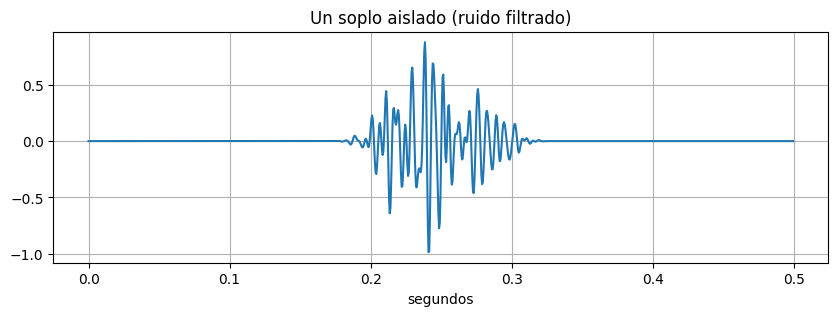

In [14]:
def soplo(t, centro, duracion, amp, fs, rng):
    out = np.zeros_like(t)
    mask = (t >= centro - duracion/2) & (t <= centro + duracion/2)
    n = mask.sum()
    if n == 0:
        return out
    ventana = np.hanning(n)
    ruido_blanco = rng.normal(0, 1, n)
    b, a = butter(4, [80/(fs/2), 250/(fs/2)], btype='band')
    ruido_filtrado = filtfilt(b, a, ruido_blanco)
    out[mask] = amp * ventana * ruido_filtrado
    return out

# probemoslo aislado, como hicimos con el pulso al principio
t_prueba = np.arange(0, 0.5, 1/FS)
ejemplo_soplo = soplo(t_prueba, centro=0.25, duracion=0.15, amp=1.0, fs=FS, rng=RNG)

plt.figure(figsize=(10, 3))
plt.plot(t_prueba, ejemplo_soplo)
plt.title('Un soplo aislado (ruido filtrado)')
plt.xlabel('segundos')
plt.show()

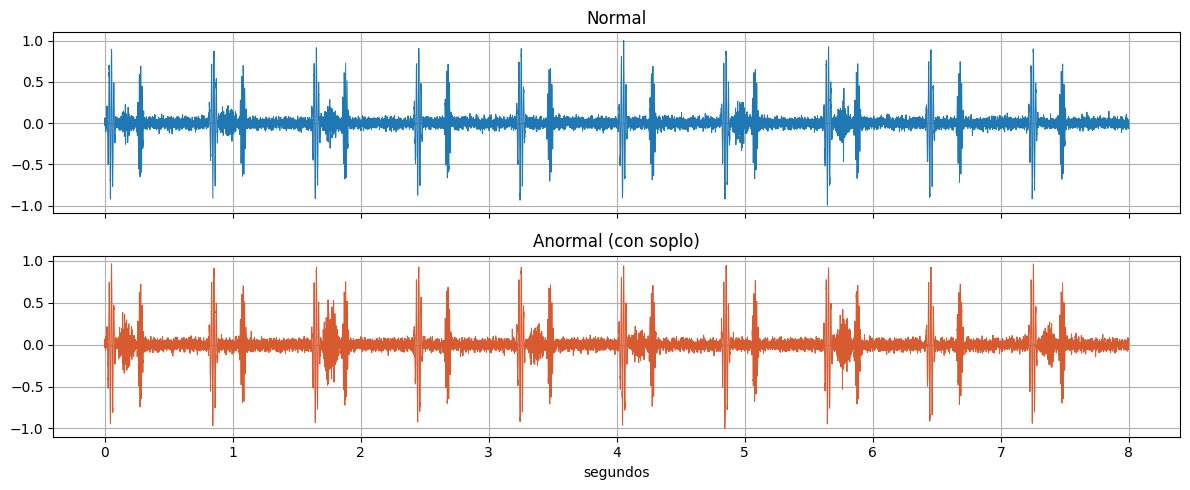

Normal:


Anormal:


In [15]:
def generar_grabacion(bpm, duracion, anormal, fs, rng):
    t = np.arange(0, duracion, 1/fs)
    cycle_len = 60.0 / bpm
    señal = np.zeros_like(t)
    n_ciclos = int(duracion / cycle_len)

    for i in range(n_ciclos):
        inicio_ciclo = i * cycle_len
        s1_centro = inicio_ciclo + 0.05
        s2_centro = inicio_ciclo + 0.35*cycle_len
        s1 = hann_pulse(t, center=s1_centro, dur=0.09, freq=55, amp=1.0)
        s2 = hann_pulse(t, center=s2_centro, dur=0.07, freq=90, amp=0.75)
        señal += s1 + s2

        centro_soplo = s1_centro + 0.5*(s2_centro - s1_centro)
        duracion_soplo = (s2_centro - s1_centro) - 0.05

        if anormal and rng.random() < 0.6:
            amp_soplo = rng.uniform(0.25, 0.7)
            señal += soplo(t, centro=centro_soplo, duracion=duracion_soplo, amp=amp_soplo, fs=fs, rng=rng)
        elif (not anormal) and rng.random() < 0.35:
            amp_soplo = rng.uniform(0.2, 0.55)
            señal += soplo(t, centro=centro_soplo, duracion=duracion_soplo, amp=amp_soplo, fs=fs, rng=rng)

    señal = señal / np.max(np.abs(señal))
    ruido = rng.normal(0, 0.04, size=t.shape)
    señal = señal + ruido
    señal = señal / np.max(np.abs(señal))
    return t, señal

t, grabacion_normal = generar_grabacion(bpm=75, duracion=8.0, anormal=False, fs=FS, rng=RNG)
t, grabacion_anormal = generar_grabacion(bpm=75, duracion=8.0, anormal=True, fs=FS, rng=RNG)

fig, axes = plt.subplots(2, 1, figsize=(12, 5), sharex=True)
axes[0].plot(t, grabacion_normal, linewidth=0.7)
axes[0].set_title('Normal')
axes[1].plot(t, grabacion_anormal, linewidth=0.7, color='#D85A30')
axes[1].set_title('Anormal (con soplo)')
axes[1].set_xlabel('segundos')
plt.tight_layout()
plt.show()

print("Normal:")
display(Audio(grabacion_normal, rate=FS))
print("Anormal:")
display(Audio(grabacion_anormal, rate=FS))

audio_int16 = (grabacion_anormal * 32767).astype(np.int16)
wavfile.write('ejemplo_latido_anormal.wav', FS, audio_int16)


In [16]:
def crear_dataset(n_pacientes, fs, rng):
    grabaciones = []
    for pid in range(n_pacientes):
        anormal = rng.random() < 0.4
        n_grabaciones = int(rng.integers(2, 5))
        bpm_base = rng.uniform(60, 100)
        for _ in range(n_grabaciones):
            bpm = bpm_base + rng.uniform(-3, 3)
            t, señal = generar_grabacion(bpm=bpm, duracion=8.0, anormal=anormal, fs=fs, rng=rng)
            grabaciones.append({
                'paciente_id': f'P{pid:03d}',
                'etiqueta': int(anormal),
                'señal': señal,
                'fs': fs
            })
    return grabaciones

dataset = crear_dataset(n_pacientes=30, fs=FS, rng=RNG)
print(f"total de grabaciones: {len(dataset)}")

etiquetas = [g['etiqueta'] for g in dataset]
print(f"normales: {etiquetas.count(0)}, anormales: {etiquetas.count(1)}")

total de grabaciones: 98
normales: 53, anormales: 45


In [17]:
filas = []
for grabacion in dataset:
    feats = extract_features(grabacion['señal'], grabacion['fs'])
    feats['paciente_id'] = grabacion['paciente_id']
    feats['etiqueta'] = grabacion['etiqueta']
    filas.append(feats)

df = pd.DataFrame(filas)
print(df.shape)
df.head()

(98, 24)


,mfcc1_promedio,mfcc1_variacion,mfcc2_promedio,mfcc2_variacion,mfcc3_promedio,mfcc3_variacion,mfcc4_promedio,mfcc4_variacion,mfcc5_promedio,mfcc5_variacion,...,mfcc8_promedio,mfcc8_variacion,env_promedio,env_variacion,env_asimetria,env_apuntamiento,intervalo_promedio,intervalo_variacion,paciente_id,etiqueta
0,-257.746247,14.263994,256.633069,14.623391,22.521569,10.702585,-53.605133,6.900603,-1.787911,6.726411,...,-19.659187,5.388847,0.073493,0.098361,2.030250,3.229617,0.433382,0.157575,P000,1
1,-263.032854,10.614525,255.074696,12.332065,20.504775,8.892025,-54.276543,6.026503,-0.080523,6.179812,...,-18.125953,4.666970,0.070771,0.096613,2.098665,3.540281,0.427471,0.150100,P000,1
2,-259.886462,13.151230,252.351006,20.514078,19.444916,10.977615,-55.244454,9.801017,-2.331034,7.279844,...,-18.446735,6.775947,0.067253,0.093812,2.213583,4.135044,0.437467,0.162433,P000,1
3,-252.104855,11.593124,260.493328,18.550902,24.002141,9.966485,-54.639092,4.690230,-3.524378,7.127407,...,-20.582454,5.388319,0.075840,0.098335,1.969418,3.015324,0.432765,0.157857,P000,1
4,-248.467477,10.312704,264.108838,19.760096,27.598609,7.408407,-49.542949,8.498986,-1.476757,6.417848,...,-20.911857,6.635785,0.089998,0.107264,1.641376,1.611334,0.322891,0.117915,P001,1


In [18]:
feature_cols = [c for c in df.columns if c not in ('paciente_id', 'etiqueta')]
print(f"{len(feature_cols)} columnas de features")
print(feature_cols)

22 columnas de features
['mfcc1_promedio', 'mfcc1_variacion', 'mfcc2_promedio', 'mfcc2_variacion', 'mfcc3_promedio', 'mfcc3_variacion', 'mfcc4_promedio', 'mfcc4_variacion', 'mfcc5_promedio', 'mfcc5_variacion', 'mfcc6_promedio', 'mfcc6_variacion', 'mfcc7_promedio', 'mfcc7_variacion', 'mfcc8_promedio', 'mfcc8_variacion', 'env_promedio', 'env_variacion', 'env_asimetria', 'env_apuntamiento', 'intervalo_promedio', 'intervalo_variacion']


In [19]:
X = df[feature_cols].values
y = df['etiqueta'].values
grupos = df['paciente_id'].values

print("X:", X.shape)
print("y:", y.shape)
print("primeros 10 valores de grupos:", grupos[:10])

X: (98, 22)
y: (98,)
primeros 10 valores de grupos: ['P000' 'P000' 'P000' 'P000' 'P001' 'P001' 'P001' 'P001' 'P002' 'P002']


In [20]:
sgkf = StratifiedGroupKFold(n_splits=5, shuffle=True, random_state=0)

for fold_num, (idx_entrena, idx_prueba) in enumerate(sgkf.split(X, y, groups=grupos)):
    pacientes_entrena = set(grupos[idx_entrena])
    pacientes_prueba = set(grupos[idx_prueba])
    interseccion = pacientes_entrena & pacientes_prueba
    print(f"Fold {fold_num}: {len(idx_entrena)} grabaciones entrena / {len(idx_prueba)} prueba "
          f"-- pacientes en ambos lados a la vez: {len(interseccion)}")

Fold 0: 79 grabaciones entrena / 19 prueba -- pacientes en ambos lados a la vez: 0
Fold 1: 80 grabaciones entrena / 18 prueba -- pacientes en ambos lados a la vez: 0
Fold 2: 84 grabaciones entrena / 14 prueba -- pacientes en ambos lados a la vez: 0
Fold 3: 72 grabaciones entrena / 26 prueba -- pacientes en ambos lados a la vez: 0
Fold 4: 77 grabaciones entrena / 21 prueba -- pacientes en ambos lados a la vez: 0


In [21]:
modelos = {
    'Regresion Logistica': LogisticRegression(max_iter=2000, class_weight='balanced'),
    'SVM': SVC(kernel='rbf', class_weight='balanced'),
    'Random Forest': RandomForestClassifier(n_estimators=200, class_weight='balanced', random_state=0),
    'Gradient Boosting': GradientBoostingClassifier(random_state=0),
}

resultados = {}
for nombre, modelo in modelos.items():
    pipe = Pipeline([('escalador', StandardScaler()), ('clf', modelo)])
    scores = cross_val_score(pipe, X, y, cv=sgkf, groups=grupos, scoring='accuracy')
    resultados[nombre] = scores
    print(f"{nombre:22s} exactitud = {scores.mean():.3f} +/- {scores.std():.3f}")

Regresion Logistica    exactitud = 0.801 +/- 0.120
SVM                    exactitud = 0.804 +/- 0.134
Random Forest          exactitud = 0.765 +/- 0.142
Gradient Boosting      exactitud = 0.765 +/- 0.103


[[44  9]
 [ 9 36]]
Sensibilidad: 0.800
Especificidad: 0.830
ROC-AUC: 0.868


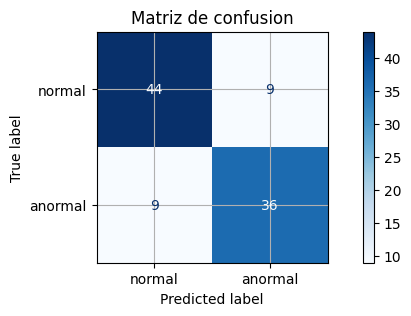

In [22]:
mejor_pipe = Pipeline([('escalador', StandardScaler()), ('clf', LogisticRegression(max_iter=2000, class_weight='balanced'))])

probabilidades = cross_val_predict(mejor_pipe, X, y, cv=sgkf, groups=grupos, method='predict_proba')
predicciones = (probabilidades[:, 1] >= 0.5).astype(int)

matriz = confusion_matrix(y, predicciones)
vn, fp, fn, vp = matriz.ravel()
sensibilidad = vp / (vp + fn)
especificidad = vn / (vn + fp)
auc = roc_auc_score(y, probabilidades[:, 1])

print(matriz)
print(f"Sensibilidad: {sensibilidad:.3f}")
print(f"Especificidad: {especificidad:.3f}")
print(f"ROC-AUC: {auc:.3f}")

ConfusionMatrixDisplay(confusion_matrix=matriz, display_labels=['normal', 'anormal']).plot(cmap='Blues')
plt.title('Matriz de confusion')
plt.show()

In [23]:
skf_naive = StratifiedKFold(n_splits=5, shuffle=True, random_state=0)

pred_naive = cross_val_predict(mejor_pipe, X, y, cv=skf_naive)
pred_agrupado = cross_val_predict(mejor_pipe, X, y, cv=sgkf, groups=grupos)

exactitud_naive = accuracy_score(y, pred_naive)
exactitud_agrupado = accuracy_score(y, pred_agrupado)

print(f"Exactitud con split NAIVE (ignora paciente):    {exactitud_naive:.3f}")
print(f"Exactitud con split AGRUPADO (por paciente):    {exactitud_agrupado:.3f}")

Exactitud con split NAIVE (ignora paciente):    0.827
Exactitud con split AGRUPADO (por paciente):    0.816


In [24]:
df_real = pd.read_excel('../pcg_processing/preprocessing/dataset_con_archivo.xlsx')

feature_cols_real = [c for c in df_real.columns if c not in ('Etiqueta', 'archivo')]
X_real = df_real[feature_cols_real].values
y_real = df_real['Etiqueta'].values
grupos_real = df_real['archivo'].values

print(f"{df_real.shape[0]} filas (ciclos) de {df_real['archivo'].nunique()} archivos")
print("\narchivos por clase:")
print(df_real.groupby('Etiqueta')['archivo'].nunique())
print("\nfilas por clase:")
print(df_real['Etiqueta'].value_counts().sort_index())

3728 filas (ciclos) de 46 archivos

archivos por clase:
Etiqueta
0    27
1     5
2    14
Name: archivo, dtype: int64

filas por clase:
Etiqueta
0    2530
1     355
2     843
Name: count, dtype: int64


In [25]:
sgkf_real = StratifiedGroupKFold(n_splits=5, shuffle=True, random_state=0)

for fold_num, (idx_entrena, idx_prueba) in enumerate(sgkf_real.split(X_real, y_real, groups=grupos_real)):
    df_prueba = df_real.iloc[idx_prueba]

    archivos_entrena = set(grupos_real[idx_entrena])
    archivos_prueba = set(grupos_real[idx_prueba])
    interseccion = archivos_entrena & archivos_prueba

    archivos_click_prueba = sorted(df_prueba[df_prueba['Etiqueta'] == 1]['archivo'].unique())
    print(f"Fold {fold_num}: repetidos entre lados = {len(interseccion)}  |  archivos de Click en prueba: {archivos_click_prueba}")

Fold 0: repetidos entre lados = 0  |  archivos de Click en prueba: ['click_01.mp3', 'click_02.mp3']
Fold 1: repetidos entre lados = 0  |  archivos de Click en prueba: ['click_03.mp3', 'click_04.mp3', 'click_05.mp3']
Fold 2: repetidos entre lados = 0  |  archivos de Click en prueba: []
Fold 3: repetidos entre lados = 0  |  archivos de Click en prueba: []
Fold 4: repetidos entre lados = 0  |  archivos de Click en prueba: []


In [26]:
for seed in range(10):
    sgkf_prueba = StratifiedGroupKFold(n_splits=5, shuffle=True, random_state=seed)
    folds_con_click = 0
    for _, idx_prueba in sgkf_prueba.split(X_real, y_real, groups=grupos_real):
        if df_real.iloc[idx_prueba][df_real.iloc[idx_prueba]['Etiqueta']==1]['archivo'].nunique() > 0:
            folds_con_click += 1
    print(f"seed={seed}: folds con Click en prueba = {folds_con_click}/5")

seed=0: folds con Click en prueba = 2/5
seed=1: folds con Click en prueba = 4/5
seed=2: folds con Click en prueba = 4/5
seed=3: folds con Click en prueba = 4/5
seed=4: folds con Click en prueba = 2/5
seed=5: folds con Click en prueba = 4/5
seed=6: folds con Click en prueba = 3/5
seed=7: folds con Click en prueba = 4/5
seed=8: folds con Click en prueba = 4/5
seed=9: folds con Click en prueba = 3/5


In [27]:
sgkf_final = StratifiedGroupKFold(n_splits=5, shuffle=True, random_state=1)

modelos = {
    'Regresion Logistica': LogisticRegression(max_iter=2000, class_weight='balanced'),
    'SVM': SVC(kernel='rbf', class_weight='balanced'),
    'Random Forest': RandomForestClassifier(n_estimators=200, class_weight='balanced', random_state=0),
    'Gradient Boosting': GradientBoostingClassifier(random_state=0),
}

for nombre, modelo in modelos.items():
    pipe = Pipeline([('escalador', StandardScaler()), ('clf', modelo)])
    scores = cross_val_score(pipe, X_real, y_real, cv=sgkf_final, groups=grupos_real, scoring='accuracy')
    print(f"{nombre:22s} exactitud = {scores.mean():.3f} +/- {scores.std():.3f}")

Regresion Logistica    exactitud = 0.999 +/- 0.002
SVM                    exactitud = 1.000 +/- 0.000
Random Forest          exactitud = 0.994 +/- 0.012
Gradient Boosting      exactitud = 0.982 +/- 0.036


In [28]:
huella = df_real.groupby('archivo')[feature_cols_real].mean().round(6)
huella_id = huella.groupby(list(feature_cols_real)).ngroup()
mapa_archivo_a_grupo = dict(zip(huella.index, huella_id))
df_real['grupo_real'] = df_real['archivo'].map(mapa_archivo_a_grupo)

print(df_real.groupby('Etiqueta')['grupo_real'].nunique())

Etiqueta
0    3
1    1
2    5
Name: grupo_real, dtype: int64


In [29]:
import pandas as pd

df_raw = pd.read_excel('../pcg_processing/preprocessing/dataset_circor.xlsx')  # ajusta la ruta si esta en otro lado
ciclos_por_archivo = df_raw.groupby('archivo').size()

for umbral in [2, 3, 5, 8]:
    archivos_ok = ciclos_por_archivo[ciclos_por_archivo >= umbral]
    print(f"umbral >= {umbral} ciclos: quedan {len(archivos_ok)} de {len(ciclos_por_archivo)} archivos ({100*len(archivos_ok)/len(ciclos_por_archivo):.0f}%)")

umbral >= 2 ciclos: quedan 1079 de 1079 archivos (100%)
umbral >= 3 ciclos: quedan 1079 de 1079 archivos (100%)
umbral >= 5 ciclos: quedan 1079 de 1079 archivos (100%)
umbral >= 8 ciclos: quedan 649 de 1079 archivos (60%)


In [30]:
for umbral in [2, 3, 5, 8]:
    archivos_ok = ciclos_por_archivo[ciclos_por_archivo >= umbral].index
    etiquetas_ok = df_raw[df_raw['archivo'].isin(archivos_ok)].drop_duplicates('archivo')['Etiqueta']
    print(f"umbral >= {umbral}: Sano={sum(etiquetas_ok==0)}  Soplo={sum(etiquetas_ok==2)}")

umbral >= 2: Sano=826  Soplo=253
umbral >= 3: Sano=826  Soplo=253
umbral >= 5: Sano=826  Soplo=253
umbral >= 8: Sano=508  Soplo=141


In [31]:
df_circor = pd.read_excel('../pcg_processing/preprocessing/dataset_circor.xlsx')  # ajusta la ruta

feature_cols_circor = [c for c in df_circor.columns if c not in ('Etiqueta', 'archivo', 'paciente_id')]
X_circor = df_circor[feature_cols_circor].values
y_circor = df_circor['Etiqueta'].values
grupos_circor = df_circor['paciente_id'].values

print(f"{df_circor.shape[0]} filas de {df_circor['paciente_id'].nunique()} pacientes")
print("\npacientes por clase:")
print(df_circor.groupby('Etiqueta')['paciente_id'].nunique())

11153 filas de 586 pacientes

pacientes por clase:
Etiqueta
0    459
2    127
Name: paciente_id, dtype: int64


In [32]:
sgkf_circor = StratifiedGroupKFold(n_splits=5, shuffle=True, random_state=0)

# chequeo rapido de fuga (mismo principio de siempre, ahora resumido)
fuga_total = 0
for idx_entrena, idx_prueba in sgkf_circor.split(X_circor, y_circor, groups=grupos_circor):
    pacientes_entrena = set(grupos_circor[idx_entrena])
    pacientes_prueba = set(grupos_circor[idx_prueba])
    fuga_total += len(pacientes_entrena & pacientes_prueba)
print(f"pacientes repetidos entre lados, sumando los 5 folds: {fuga_total}")

modelos = {
    'Regresion Logistica': LogisticRegression(max_iter=2000, class_weight='balanced'),
    'SVM': SVC(kernel='rbf', class_weight='balanced'),
    'Random Forest': RandomForestClassifier(n_estimators=200, class_weight='balanced', random_state=0),
    'Gradient Boosting': GradientBoostingClassifier(random_state=0),
}

for nombre, modelo in modelos.items():
    pipe = Pipeline([('escalador', StandardScaler()), ('clf', modelo)])
    scores = cross_val_score(pipe, X_circor, y_circor, cv=sgkf_circor, groups=grupos_circor, scoring='accuracy')
    print(f"{nombre:22s} exactitud = {scores.mean():.3f} +/- {scores.std():.3f}")

pacientes repetidos entre lados, sumando los 5 folds: 0
Regresion Logistica    exactitud = 0.673 +/- 0.017
SVM                    exactitud = 0.708 +/- 0.023
Random Forest          exactitud = 0.791 +/- 0.014
Gradient Boosting      exactitud = 0.791 +/- 0.012


[[8400  249]
 [2071  433]]
Sensibilidad (detectar Soplo): 0.173
Especificidad (no alarmar de mas): 0.971
ROC-AUC: 0.706


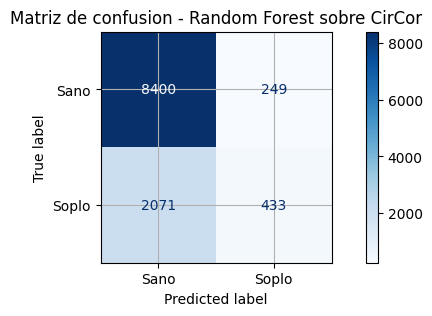

In [33]:
mejor_pipe_circor = Pipeline([('escalador', StandardScaler()), ('clf', RandomForestClassifier(n_estimators=200, class_weight='balanced', random_state=0))])

probabilidades_circor = cross_val_predict(mejor_pipe_circor, X_circor, y_circor, cv=sgkf_circor, groups=grupos_circor, method='predict_proba')
predicciones_circor = (probabilidades_circor[:, 1] >= 0.5).astype(int) * 2   # da 0 o 2, no 0 o 1

matriz_circor = confusion_matrix(y_circor, predicciones_circor)
vn, fp, fn, vp = matriz_circor.ravel()
sensibilidad = vp / (vp + fn)
especificidad = vn / (vn + fp)
auc_circor = roc_auc_score(y_circor, probabilidades_circor[:, 1])

print(matriz_circor)
print(f"Sensibilidad (detectar Soplo): {sensibilidad:.3f}")
print(f"Especificidad (no alarmar de mas): {especificidad:.3f}")
print(f"ROC-AUC: {auc_circor:.3f}")

ConfusionMatrixDisplay(confusion_matrix=matriz_circor, display_labels=['Sano', 'Soplo']).plot(cmap='Blues')
plt.title('Matriz de confusion - Random Forest sobre CirCor')
plt.show()

In [34]:
umbrales = [0.5, 0.4, 0.3, 0.25, 0.2, 0.15, 0.1]

print(f"{'umbral':>8} {'sensibilidad':>13} {'especificidad':>15}")
for umbral in umbrales:
    pred = (probabilidades_circor[:, 1] >= umbral).astype(int) * 2
    m = confusion_matrix(y_circor, pred)
    tn, fp, fn, vp = m.ravel()
    sens = vp / (vp + fn)
    esp = tn / (tn + fp)
    print(f"{umbral:>8.2f} {sens:>13.3f} {esp:>15.3f}")

  umbral  sensibilidad   especificidad
    0.50         0.173           0.971
    0.40         0.275           0.936
    0.30         0.418           0.854
    0.25         0.515           0.783
    0.20         0.635           0.669
    0.15         0.756           0.508
    0.10         0.885           0.295


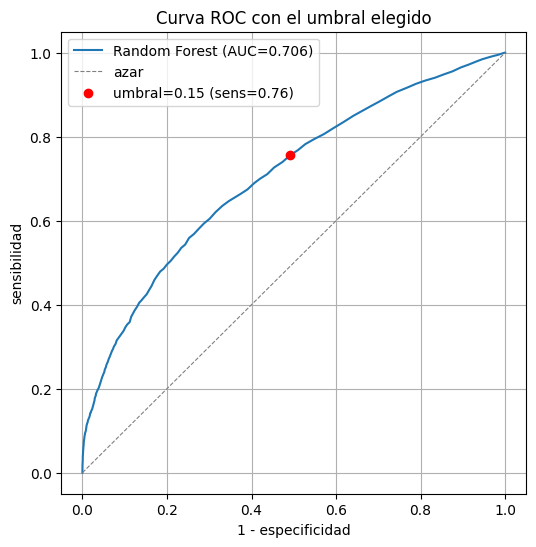

In [35]:
umbral_elegido = 0.15  # 50% de falsas alarmas

fpr, tpr, umbrales_roc = roc_curve(y_circor, probabilidades_circor[:, 1], pos_label=2)

plt.figure(figsize=(6, 6))
plt.plot(fpr, tpr, label=f'Random Forest (AUC={auc_circor:.3f})')
plt.plot([0, 1], [0, 1], '--', color='gray', linewidth=0.8, label='azar')

idx_cercano = np.argmin(np.abs(umbrales_roc - umbral_elegido))
plt.scatter(fpr[idx_cercano], tpr[idx_cercano], color='red', zorder=5,
            label=f'umbral={umbral_elegido} (sens={tpr[idx_cercano]:.2f})')

plt.xlabel('1 - especificidad')
plt.ylabel('sensibilidad')
plt.legend()
plt.title('Curva ROC con el umbral elegido')
plt.show()

In [36]:
df_circor['prob_soplo'] = probabilidades_circor[:, 1]
df_circor['prediccion_ciclo'] = (df_circor['prob_soplo'] >= 0.15).astype(int) * 2

def voto_mayoria(grupo):
    return grupo.value_counts().idxmax()

predicciones_paciente = df_circor.groupby('paciente_id')['prediccion_ciclo'].apply(voto_mayoria)
etiquetas_paciente = df_circor.groupby('paciente_id')['Etiqueta'].first()

matriz_paciente = confusion_matrix(etiquetas_paciente, predicciones_paciente)
tn, fp, fn, vp = matriz_paciente.ravel()
sens_paciente = vp / (vp + fn)
esp_paciente = tn / (tn + fp)

print("Por ciclo (celda 27, umbral 0.15): sensibilidad=0.756")
print(f"Por paciente (voto de mayoria):    sensibilidad={sens_paciente:.3f}  especificidad={esp_paciente:.3f}")
print(matriz_paciente)

Por ciclo (celda 27, umbral 0.15): sensibilidad=0.756
Por paciente (voto de mayoria):    sensibilidad=0.835  especificidad=0.514
[[236 223]
 [ 21 106]]


In [37]:
print(f"{'umbral':>8} {'sensibilidad':>13} {'especificidad':>15}")
for umbral in [0.5, 0.4, 0.3, 0.25, 0.2, 0.15, 0.1, 0.05]:
    df_circor['prediccion_ciclo'] = (df_circor['prob_soplo'] >= umbral).astype(int) * 2
    pred_paciente = df_circor.groupby('paciente_id')['prediccion_ciclo'].apply(voto_mayoria)
    m = confusion_matrix(etiquetas_paciente, pred_paciente)
    tn, fp, fn, vp = m.ravel()
    sens = vp / (vp + fn)
    esp = tn / (tn + fp)
    print(f"{umbral:>8.2f} {sens:>13.3f} {esp:>15.3f}")

  umbral  sensibilidad   especificidad
    0.50         0.150           0.991
    0.40         0.252           0.956
    0.30         0.386           0.913
    0.25         0.488           0.856
    0.20         0.701           0.741
    0.15         0.835           0.514
    0.10         0.953           0.255
    0.05         1.000           0.031


In [38]:
print(f"{'umbral':>8} {'sensibilidad':>13} {'especificidad':>15} {'Youden J':>10}")
for umbral in [0.5, 0.4, 0.3, 0.25, 0.2, 0.15, 0.1, 0.05]:
    df_circor['prediccion_ciclo'] = (df_circor['prob_soplo'] >= umbral).astype(int) * 2
    pred_paciente = df_circor.groupby('paciente_id')['prediccion_ciclo'].apply(voto_mayoria)
    m = confusion_matrix(etiquetas_paciente, pred_paciente)
    tn, fp, fn, vp = m.ravel()
    sens = vp / (vp + fn)
    esp = tn / (tn + fp)
    j = sens + esp - 1
    print(f"{umbral:>8.2f} {sens:>13.3f} {esp:>15.3f} {j:>10.3f}")

  umbral  sensibilidad   especificidad   Youden J
    0.50         0.150           0.991      0.141
    0.40         0.252           0.956      0.208
    0.30         0.386           0.913      0.299
    0.25         0.488           0.856      0.344
    0.20         0.701           0.741      0.442
    0.15         0.835           0.514      0.349
    0.10         0.953           0.255      0.208
    0.05         1.000           0.031      0.031


In [39]:
#umbral=.20

In [40]:
modelo_final = Pipeline([('escalador', StandardScaler()), ('clf', RandomForestClassifier(n_estimators=200, class_weight='balanced', random_state=0))])
modelo_final.fit(X_circor, y_circor)

import joblib
joblib.dump(modelo_final, 'modelo_pcg_soplo_rf.joblib')

import json
metadata = {
    'feature_cols': feature_cols_circor,
    'umbral_decision': 0.20,
    'clases': {'0': 'Sano', '2': 'Soplo'},
}
with open('modelo_pcg_soplo_rf_metadata.json', 'w') as f:
    json.dump(metadata, f, indent=2)

print("Modelo guardado en modelo_pcg_soplo_rf.joblib")
print("Metadata guardada en modelo_pcg_soplo_rf_metadata.json")

Modelo guardado en modelo_pcg_soplo_rf.joblib
Metadata guardada en modelo_pcg_soplo_rf_metadata.json


>> python arboldeprediccion.py "C:\Users\emigo\OneDrive\Documentos\Servicio Social\the-circor-digiscope-phonocardiogram-dataset-1.0.3\the-circor-digiscope-phonocardiogram-dataset-1.0.3\training_data\2530_MV.wav" | python -c "import json,sys; d=json.load(sys.stdin); d.pop('pipeline',None); print(json.dumps(d, indent=2, ensure_ascii=False))"
{
  "status": "success",
  "class": "Sano",
  "confidence": 100.0,
  "cycles": 18,
  "bpm": 41.1,
  "fs": 4000,
  "duration": 26.69
}

In [41]:
sgkf_split = StratifiedGroupKFold(n_splits=5, shuffle=True, random_state=42)
idx_dev, idx_prueba_final = next(sgkf_split.split(X_circor, y_circor, groups=grupos_circor))

X_dev, y_dev, grupos_dev = X_circor[idx_dev], y_circor[idx_dev], grupos_circor[idx_dev]
X_prueba_final, y_prueba_final, grupos_prueba_final = X_circor[idx_prueba_final], y_circor[idx_prueba_final], grupos_circor[idx_prueba_final]

pacientes_dev = set(grupos_dev)
pacientes_prueba_final = set(grupos_prueba_final)
print(f"pacientes repetidos entre dev y prueba final: {len(pacientes_dev & pacientes_prueba_final)}")
print(f"dev: {len(idx_dev)} filas, {len(pacientes_dev)} pacientes")
print(f"prueba final (nunca se toca hasta el final): {len(idx_prueba_final)} filas, {len(pacientes_prueba_final)} pacientes")

pacientes repetidos entre dev y prueba final: 0
dev: 9000 filas, 469 pacientes
prueba final (nunca se toca hasta el final): 2153 filas, 117 pacientes


In [42]:
sgkf_dev = StratifiedGroupKFold(n_splits=5, shuffle=True, random_state=0)

pipe_rf = Pipeline([('escalador', StandardScaler()), ('clf', RandomForestClassifier(n_estimators=200, class_weight='balanced', random_state=0))])
proba_dev = cross_val_predict(pipe_rf, X_dev, y_dev, cv=sgkf_dev, groups=grupos_dev, method='predict_proba')

df_dev = pd.DataFrame({'paciente_id': grupos_dev, 'Etiqueta': y_dev, 'prob_soplo': proba_dev[:, 1]})
etiquetas_dev_paciente = df_dev.groupby('paciente_id')['Etiqueta'].first()

print(f"{'umbral':>8} {'sensibilidad':>13} {'especificidad':>15} {'Youden J':>10}")
mejor_j, mejor_umbral = -1, None
for umbral in [0.5, 0.4, 0.3, 0.25, 0.2, 0.15, 0.1]:
    df_dev['pred_ciclo'] = (df_dev['prob_soplo'] >= umbral).astype(int) * 2
    pred_paciente = df_dev.groupby('paciente_id')['pred_ciclo'].apply(voto_mayoria)
    m = confusion_matrix(etiquetas_dev_paciente, pred_paciente)
    tn, fp, fn, vp = m.ravel()
    sens, esp = vp/(vp+fn), tn/(tn+fp)
    j = sens + esp - 1
    print(f"{umbral:>8.2f} {sens:>13.3f} {esp:>15.3f} {j:>10.3f}")
    if j > mejor_j:
        mejor_j, mejor_umbral = j, umbral

print(f"\numbral elegido (mejor Youden J, solo con datos de dev): {mejor_umbral}")

  umbral  sensibilidad   especificidad   Youden J
    0.50         0.097           0.989      0.086
    0.40         0.172           0.989      0.161
    0.30         0.280           0.968      0.248
    0.25         0.398           0.923      0.321
    0.20         0.527           0.851      0.378
    0.15         0.677           0.705      0.382
    0.10         0.839           0.415      0.254

umbral elegido (mejor Youden J, solo con datos de dev): 0.15


In [43]:
modelo_dev = Pipeline([('escalador', StandardScaler()), ('clf', RandomForestClassifier(n_estimators=200, class_weight='balanced', random_state=0))])
modelo_dev.fit(X_dev, y_dev)

proba_final = modelo_dev.predict_proba(X_prueba_final)[:, 1]

df_final = pd.DataFrame({'paciente_id': grupos_prueba_final, 'Etiqueta': y_prueba_final, 'prob_soplo': proba_final})
df_final['pred_ciclo'] = (df_final['prob_soplo'] >= mejor_umbral).astype(int) * 2
pred_paciente_final = df_final.groupby('paciente_id')['pred_ciclo'].apply(voto_mayoria)
etiquetas_paciente_final = df_final.groupby('paciente_id')['Etiqueta'].first()

m_final = confusion_matrix(etiquetas_paciente_final, pred_paciente_final)
tn, fp, fn, vp = m_final.ravel()
print(f"EXAMEN FINAL, con {len(etiquetas_paciente_final)} pacientes que el modelo nunca vio:")
print(f"Sensibilidad: {vp/(vp+fn):.3f}   Especificidad: {tn/(tn+fp):.3f}")
print(m_final)

EXAMEN FINAL, con 117 pacientes que el modelo nunca vio:
Sensibilidad: 0.735   Especificidad: 0.699
[[58 25]
 [ 9 25]]


In [44]:
modelo_final = Pipeline([('escalador', StandardScaler()), ('clf', RandomForestClassifier(n_estimators=200, class_weight='balanced', random_state=0))])
modelo_final.fit(X_circor, y_circor)

joblib.dump(modelo_final, 'modelo_pcg_soplo_rf.joblib')

metadata = {
    'feature_cols': feature_cols_circor,
    'umbral_decision': 0.15,
    'clases': {'0': 'Sano', '2': 'Soplo'},
    'metricas_examen_final': {'sensibilidad': 0.735, 'especificidad': 0.699, 'n_pacientes_prueba': 117},
}
with open('modelo_pcg_soplo_rf_metadata.json', 'w') as f:
    json.dump(metadata, f, indent=2)

print("Modelo actualizado con umbral validado correctamente")

Modelo actualizado con umbral validado correctamente


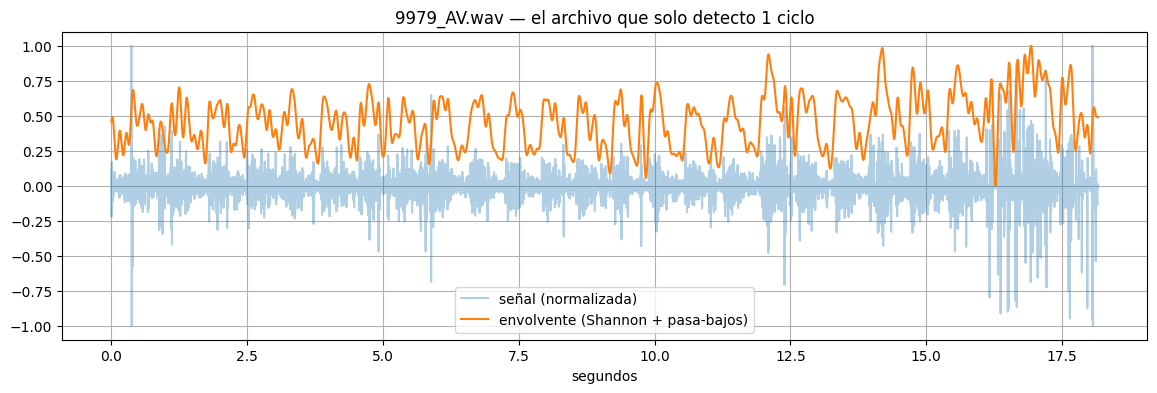

In [45]:
def preprocess_audio(file_path):
    x, fs = librosa.load(file_path, sr=None, mono=True)
    x = x / (np.max(np.abs(x)) + 1e-12)
    t = np.arange(len(x)) / fs
    return x, fs, t

def compute_shannon_envelope(x, fs):
    p = np.abs(x)
    p = p / (np.max(p) + 1e-12)
    E = -p * np.log10(p + 1e-12)
    E_z = (E - np.mean(E)) / (np.std(E) + 1e-12)
    Env0 = (E_z - np.min(E_z)) / (np.max(E_z) - np.min(E_z) + 1e-12)
    fc = 9
    b, a = butter(4, fc / (fs / 2), 'low')
    Env = filtfilt(b, a, Env0)
    Env = (Env - np.min(Env)) / (np.max(Env) - np.min(Env) + 1e-12)
    return Env

ruta_problema = r"C:\Users\emigo\OneDrive\Documentos\Servicio Social\the-circor-digiscope-phonocardiogram-dataset-1.0.3\the-circor-digiscope-phonocardiogram-dataset-1.0.3\training_data\9979_AV.wav"

x, fs, t = preprocess_audio(ruta_problema)
Env = compute_shannon_envelope(x, fs)

plt.figure(figsize=(14, 4))
plt.plot(t, x, alpha=0.35, label='señal (normalizada)')
plt.plot(t, Env, linewidth=1.5, label='envolvente (Shannon + pasa-bajos)')
plt.legend()
plt.xlabel('segundos')
plt.title('9979_AV.wav — el archivo que solo detecto 1 ciclo')
plt.show()

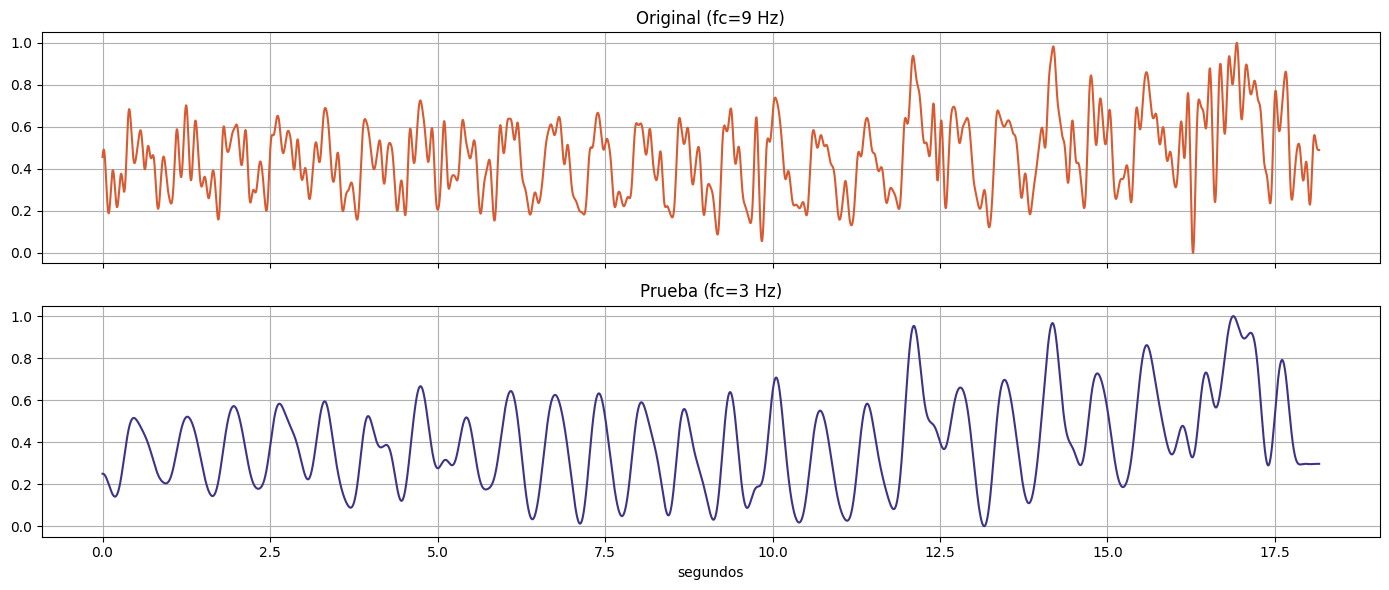

In [ ]:
def compute_shannon_envelope_v2(x, fs, fc=3):
    p = np.abs(x)
    p = p / (np.max(p) + 1e-12)
    E = -p * np.log10(p + 1e-12)
    E_z = (E - np.mean(E)) / (np.std(E) + 1e-12)
    Env0 = (E_z - np.min(E_z)) / (np.max(E_z) - np.min(E_z) + 1e-12)
    b, a = butter(4, fc / (fs / 2), 'low')
    Env = filtfilt(b, a, Env0)
    Env = (Env - np.min(Env)) / (np.max(Env) - np.min(Env) + 1e-12)
    return Env

Env_v2 = compute_shannon_envelope_v2(x, fs, fc=3)

fig, axes = plt.subplots(2, 1, figsize=(14, 6), sharex=True, sharey=True)
axes[0].plot(t, Env, color='#D85A30')
axes[0].set_title('Original (fc=9 Hz)')
axes[1].plot(t, Env_v2, color='#3C3489')
axes[1].set_title('Prueba (fc=3 Hz)')
axes[1].set_xlabel('segundos')
plt.tight_layout()
plt.show()